# GISLR — why continuous recognition breaks live: input-robustness probes for C1 and C1 v2 (TODO §12.8)

**Diagnostic, not a pipeline stage. Inference only — no training.**

The user's first camera test of the web app (2026-09-25): isolated signs are recognized well, but
continuous sentences are "garbage" — missing, extra and wrong glosses. Offline, C1 + D3 scores GER 0.293
on GISLR-Sentences. This notebook measures how fast that number falls when the input drifts the way a
live webcam differs from GISLR. The model reads **raw MediaPipe `xy` in image coordinates** (ME_132, no
normalization), was trained on **streams of 1–6 signs (≤600 frames) from zero state**, and learned
transitions from **linear interpolation**.

Each probe transforms the evaluation-signer `sentence` streams. Each is scored two ways:

- **stream GER** under C1 + D3 (ν = 0.7, min_len 4, collapsed: the offline best, `continuous-models.md`);
- **isolated accuracy**: each true sign segment fed alone from zero state (the "individual recognition" the
  user says works).

If a probe hurts the stream far more than isolated accuracy, it explains the user's observation.

| artifact | path |
|---|---|
| per-probe results (resumable, one file per probe) | `data/cache/gislr/live_robustness/parts/<probe>.json` |
| summary table | `data/cache/gislr/live_robustness/summary.csv` |
| GISLR framing reference | `data/cache/gislr/live_robustness/framing.json` |
| figure | `data/cache/gislr/live_robustness/assets/probes.png` |

**C1 v2 (2026-09-26):** the same probes also score **C4** (stream normalization + augmented training) and **C5** (augmented training, raw input), one part folder per run (`parts/<run>/`; C1 keeps `parts/`). A run that is not trained yet is skipped.

**Resumable:** a probe whose part file exists is skipped. The sample of streams is seeded and saved.

## 1. Setup

In [1]:
# ============================================================
# Imports, tunables, C1, GISLR-Sentences evaluation streams
# ============================================================
import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from tqdm.auto import tqdm

from sb.core.paths import CACHE_DIR, gislr_sentences_dir
from sb.core.subsets import SUBSETS
from sb.recognize import streaming as S
from sb.recognize.continuous import decode as CDEC
from sb.recognize.continuous.train import load_run, run_dir_for
from sb.recognize.sequences import baselines as B
from sb.recognize.sequences import metrics as M

RUNS = ["C1", "C4", "C5"]  # C1 first: the framing reference and the reframe targets come from its streams
N_STREAMS = 400          # evaluation-signer `sentence` streams per probe (seeded)
SEED = 42
NU, MIN_LEN = 0.7, 4     # C1 D3 collapsed, chosen on the selection signers (continuous-models.md)
N_SELECTION_SIGNERS = 5  # same signer split as the continuous eval
CHAIN = 6                # streams per chained long session (probe `long_session`)

OUT = CACHE_DIR / "gislr" / "live_robustness"
PARTS = OUT / "parts"
ASSETS = OUT / "assets"
for d in (PARTS, ASSETS):
    d.mkdir(parents=True, exist_ok=True)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_grad_enabled(False)

ROOT = gislr_sentences_dir("v1")
SEQ = pd.read_csv(ROOT / "sequences.csv", keep_default_na=False)
SEQ["row"] = np.arange(len(SEQ))
SELECT, EVAL = B.signer_split(SEQ["participant_id"], N_SELECTION_SIGNERS, SEED)
pool = SEQ[SEQ.participant_id.isin(EVAL) & (SEQ.kind == "sentence")]
SAMPLE = pool.sample(N_STREAMS, random_state=SEED).sort_values(["participant_id", "row"])
(OUT / "sample_rows.json").write_text(json.dumps(SAMPLE["row"].tolist()))

MODELS = {}
for run in RUNS:
    rd = run_dir_for(run)
    if rd is None or not (rd / "meta.json").exists() or not json.loads((rd / "meta.json").read_text())["training"]["finished"]:
        print(f"{run}: not trained -- skipped")
        continue
    m, ck = load_run(rd, DEVICE)
    MODELS[run] = {"model": m, "arch": ck["arch"], "null": ck["null_index"], "rows": np.asarray(ck["landmarks"]),
                   "coords": ck["coords"], "run_dir": rd}
ROWS = MODELS["C1"]["rows"]
assert all(r["coords"] == "xy" and np.array_equal(r["rows"], ROWS) for r in MODELS.values()), \
    "every probed run must read ME_132 xy (the probes edit those columns)"
FEATS = B.StreamFeatures.build(ROOT, SEQ, ROWS, "xy")

# column of (landmark row, coord) in the (T, 2*132) feature vector
POS = {int(r): i for i, r in enumerate(ROWS)}
def col(row, c):  # c: 0 = x, 1 = y
    return 2 * POS[row] + c
LH = [r for r in range(468, 489) if r in POS]
RH = [r for r in range(522, 543) if r in POS]
P = lambda k: 489 + k  # pose landmark k -> holistic row
POSE_LR = [(P(a), P(b)) for a, b in [(11, 12), (13, 14), (15, 16), (17, 18), (19, 20), (21, 22), (23, 24)] if P(a) in POS]
print(f"runs: {[f'{r} {v['run_dir'].name} {v['arch']}' for r, v in MODELS.items()]} · "
      f"{len(ROWS)} landmarks · {len(SAMPLE)} streams from {len(EVAL)} signers")
print(f"results -> {OUT}")

gislr_sentences_dir: kaggle copy unavailable (KaggleApiHTTPError); using the local build C:\Users\user2\repository\data\cache\gislr\sentences\v1
runs: ['C1 1790429419 gru_continuous', 'C4 1790435218 gru_continuous_norm', 'C5 1790435219 gru_continuous'] · 132 landmarks · 400 streams from 16 signers
results -> C:\Users\user2\repository\data\cache\gislr\live_robustness


## 2. Probes

A probe maps one stream `(x, kinds, labels, segments)` to a transformed one. Missing landmarks are
`(0, 0)` in the model input (NaN → 0), and every geometric probe leaves them at 0.

| probe | what a live camera does that GISLR did not |
|---|---|
| `shift_x±`, `shift_y+` | signer off-centre / lower in frame (0.1 of the image) |
| `scale_0.7`, `scale_1.3` | signer farther from / closer to the camera |
| `aspect_0.56` | a 16:9 landscape webcam vs a portrait phone: x is squashed about the centre (0.56 ≈ 4:3 → 16:9; a 9:16 → 16:9 change would be 0.32) |
| `mirror` | x flipped and left/right hands and arms swapped: a left-handed signer or a wrong mirror setting |
| `fps_15`, `fps_10` | Holistic on CPU below 30 fps: the app's clock repeats each frame 2× / 3× |
| `speed_1.5` | natural continuous signing is faster than citation-form clips |
| `jitter_0.01` | landmark noise of 1% of the image |
| `hand_drop_0.2` | a hand flickers out in 20% of frames |
| `long_session` | 6 streams chained with no state reset: the app resets only after 45 null frames |

In [2]:
# ============================================================
# Probe definitions
# ============================================================
def present(x):
    return (x[:, 0::2] != 0) | (x[:, 1::2] != 0)  # (T, L)


def affine(x, ax=1.0, bx=0.0, ay=1.0, by=0.0, cx=0.5, cy=0.5):
    y = x.copy()
    m = present(x)
    X, Y = y[:, 0::2], y[:, 1::2]
    X[m] = (X[m] - cx) * ax + cx + bx
    Y[m] = (Y[m] - cy) * ay + cy + by
    return y


def mirror(x):
    y = affine(x, ax=-1.0)
    z = y.copy()
    for a, b in list(zip(LH, RH)) + POSE_LR:
        for c in (0, 1):
            z[:, col(a, c)], z[:, col(b, c)] = y[:, col(b, c)], y[:, col(a, c)]
    return z


def fps(x, k):  # a k-times slower camera; the app's clock repeats each frame k times
    idx = (np.arange(len(x)) // k) * k
    return x[idx]


def jitter(x, s, rng):
    y = x + rng.normal(0, s, x.shape).astype(np.float32)
    y[np.repeat(~present(x), 2, axis=1)] = 0
    return y


def hand_drop(x, p, rng):
    y = x.copy()
    for hand in (LH, RH):
        cols = [col(r, c) for r in hand for c in (0, 1)]
        drop = rng.random(len(x)) < p
        y[np.ix_(drop, cols)] = 0
    return y


def retime(x, kinds, seg, speed):
    idx = np.unique(np.round(np.arange(0, len(x), speed)).astype(int).clip(0, len(x) - 1))
    s = np.searchsorted(idx, seg[:, 0])
    e = np.maximum(np.searchsorted(idx, seg[:, 1]), s + 1)
    return x[idx], kinds[idx], np.stack([s, e], 1)


PROBES = {
    "none": lambda x, r: x,
    "shift_x+0.1": lambda x, r: affine(x, bx=0.1),
    "shift_x-0.1": lambda x, r: affine(x, bx=-0.1),
    "shift_y+0.1": lambda x, r: affine(x, by=0.1),
    "scale_0.7": lambda x, r: affine(x, ax=0.7, ay=0.7),
    "scale_1.3": lambda x, r: affine(x, ax=1.3, ay=1.3),
    "aspect_0.56": lambda x, r: affine(x, ax=0.56),
    "mirror": lambda x, r: mirror(x),
    "fps_15": lambda x, r: fps(x, 2),
    "fps_10": lambda x, r: fps(x, 3),
    "jitter_0.01": lambda x, r: jitter(x, 0.01, r),
    "hand_drop_0.2": lambda x, r: hand_drop(x, 0.2, r),
    "speed_1.5": "retime",
    "long_session": "chain",
}

### 2b. App-side fixes (no retraining)

Each fix is something the web app can do before the model sees a frame:

- **`interp`**: on a slow camera, interpolate landmarks linearly between the two real frames around each
  30 fps tick instead of repeating the last one. This costs one camera frame of latency.
- **`ema`**: a causal exponential moving average over each landmark (α = weight of the new frame). A
  hand that reappears restarts its average.
- **`reframe`**: a per-session affine calibration. It moves the signer's median shoulder midpoint to where
  GISLR signers sit, scales x by shoulder width, and scales y by the shoulder-to-nose height. The targets are
  the clean sample's medians (§4). The app would measure the signer's values over the first seconds.

In [3]:
# ============================================================
# Fixes, and a combined "live-like" degradation with and without them
# ============================================================
def fps_interp(x, k):
    idx = np.arange(len(x))
    lo = (idx // k) * k
    hi = np.minimum(lo + k, len(x) - 1)
    w = ((idx - lo) / k).astype(np.float32)[:, None]
    y = x[lo] * (1 - w) + x[hi] * w
    both = np.repeat(present(x[lo]) & present(x[hi]), 2, axis=1)
    return np.where(both, y, x[lo])


def ema(x, a):
    y = x.copy()
    m = np.repeat(present(x), 2, axis=1)
    for t in range(1, len(x)):
        keep = m[t] & m[t - 1]
        y[t, keep] = a * x[t, keep] + (1 - a) * y[t - 1, keep]
    return y


def shoulder_frame(x):
    ls, rs, nz = P(11), P(12), 1  # face-mesh nose tip (pose nose is not in ME_132)
    ok = (x[:, col(ls, 0)] != 0) & (x[:, col(rs, 0)] != 0) & (x[:, col(nz, 1)] != 0)
    if not ok.any():
        return None
    mx = (x[ok, col(ls, 0)] + x[ok, col(rs, 0)]) / 2
    my = (x[ok, col(ls, 1)] + x[ok, col(rs, 1)]) / 2
    w = np.abs(x[ok, col(ls, 0)] - x[ok, col(rs, 0)])
    h = my - x[ok, col(nz, 1)]
    return np.median(mx), np.median(my), np.median(w), np.median(h)


_ref = np.array([shoulder_frame(FEATS.x(i)) for i in SAMPLE["row"]], dtype=float)
REF = dict(zip(("mx", "my", "w", "h"), np.nanmedian(_ref, axis=0)))
print("reframe targets (GISLR medians):", {k: round(float(v), 3) for k, v in REF.items()})


def reframe(x):
    f = shoulder_frame(x)
    if f is None:
        return x
    mx, my, w, h = f
    return affine(x, ax=REF["w"] / w, ay=REF["h"] / h, cx=mx, cy=my, bx=REF["mx"] - mx, by=REF["my"] - my)


def live_like(x, r):  # farther away and lower in frame, 15 fps, jitter, flickering hands
    return hand_drop(jitter(fps(affine(x, ax=0.8, ay=0.8, by=0.05), 2), 0.005, r), 0.1, r)


def live_like_fixed(x, r):  # same degradations; the app interpolates, smooths and reframes
    y = hand_drop(jitter(fps_interp(affine(x, ax=0.8, ay=0.8, by=0.05), 2), 0.005, r), 0.1, r)
    return ema(reframe(y), 0.5)


PROBES.update({
    "fps_15+interp": lambda x, r: fps_interp(x, 2),
    "fps_10+interp": lambda x, r: fps_interp(x, 3),
    "jitter_0.005": lambda x, r: jitter(x, 0.005, r),
    "jitter_0.01+ema0.5": lambda x, r: ema(jitter(x, 0.01, r), 0.5),
    "jitter_0.01+ema0.3": lambda x, r: ema(jitter(x, 0.01, r), 0.3),
    "none+ema0.5": lambda x, r: ema(x, 0.5),
    "none+reframe": lambda x, r: reframe(x),
    "aspect_0.56+reframe": lambda x, r: reframe(affine(x, ax=0.56)),
    "scale_0.7+reframe": lambda x, r: reframe(affine(x, ax=0.7, ay=0.7)),
    "live_like": live_like,
    "live_like+fixes": live_like_fixed,
})

reframe targets (GISLR medians): {'mx': 0.498, 'my': 0.629, 'w': 0.565, 'h': 0.225}


## 3. Run every probe (stream GER + isolated accuracy)

In [4]:
# ============================================================
# Score each probe; one part file per probe (resumable)
# ============================================================
def stream(i):
    row = SEQ.iloc[i]
    labels, seg = B.seq_arrays(row)
    return FEATS.x(i).copy(), FEATS.kind(i).copy(), labels, seg


def score(r, x, kinds, labels, seg, iso=True):
    xt = torch.from_numpy(np.ascontiguousarray(x))
    gp, _ = CDEC.frame_outputs(r["model"], xt)
    em = S.collapse_repeats(CDEC.decode_null(gp, NU, MIN_LEN, r["null"]))
    sc = M.score_sequence(em, labels, seg, kinds)
    hits = ([int(S.clip_probs(r["model"], r["arch"], xt[s:e]).argmax() == lab) for (s, e), lab in zip(seg, labels)]
            if iso else [])
    return sc, hits


def chains():
    for pid, g in SAMPLE.groupby("participant_id"):
        rows = g["row"].tolist()
        for j in range(0, len(rows) - CHAIN + 1, CHAIN):
            parts = [stream(i) for i in rows[j:j + CHAIN]]
            off = np.cumsum([0] + [len(p[0]) for p in parts[:-1]])
            yield (np.concatenate([p[0] for p in parts]), np.concatenate([p[1] for p in parts]),
                   np.concatenate([p[2] for p in parts]), np.concatenate([p[3] + o for p, o in zip(parts, off)]),
                   [len(p[2]) for p in parts])


def part_dir(run):
    return PARTS if run == "C1" else PARTS / run  # C1's parts predate v2


JOBS = [(run, name, fn) for run in MODELS for name, fn in PROBES.items()]
for run, name, fn in JOBS:
    r = MODELS[run]
    path = part_dir(run) / f"{name}.json"
    path.parent.mkdir(parents=True, exist_ok=True)
    if path.exists():
        continue
    rng = np.random.default_rng(SEED)
    scores, hits, kinds_all, by_pos = [], [], [], {}
    if fn == "chain":
        for x, kinds, labels, seg, sizes in tqdm(list(chains()), desc=f"{run} {name}"):
            sc, _ = score(r, x, kinds, labels, seg, iso=False)
            scores.append(sc)
            kinds_all.append(kinds)
            # which part of the chain each reference sign sits in
            pos = np.repeat(np.arange(len(sizes)), sizes)
            for p_, ok in zip(pos, sc["ref_correct"]):
                by_pos.setdefault(int(p_), []).append(bool(ok))
    else:
        for i in tqdm(SAMPLE["row"].tolist(), desc=f"{run} {name}"):
            x, kinds, labels, seg = stream(i)
            if fn == "retime":
                x, kinds, seg = retime(x, kinds, seg, 1.5)
            else:
                x = fn(x, rng)
            sc, h = score(r, x, kinds, labels, seg)
            scores.append(sc)
            hits += h
            kinds_all.append(kinds)
    agg = M.aggregate(scores, B.frame_totals(kinds_all))
    res = {"run": run, "probe": name, "ger": agg["ger"], "sub": agg["sub_rate"], "del": agg["del_rate"],
           "ins": agg["ins_rate"], "correct": agg["correct_rate"], "n_ref": agg["n_ref"],
           "isolated_acc": float(np.mean(hits)) if hits else None,
           "recall_by_chain_position": {k: float(np.mean(v)) for k, v in sorted(by_pos.items())} or None}
    tmp = path.with_suffix(".tmp")
    tmp.write_text(json.dumps(res, indent=1))
    os.replace(tmp, path)

rows_ = []
for run in MODELS:
    for p_ in sorted(part_dir(run).glob("*.json")):
        rows_.append({**json.loads(p_.read_text()), "run": run})
SUMMARY = pd.DataFrame(rows_).set_index(["run", "probe"])
SUMMARY = SUMMARY.loc[[(run, k) for run in MODELS for k in PROBES if (run, k) in SUMMARY.index]]
base = SUMMARY.xs("none", level="probe")
SUMMARY["Δger"] = SUMMARY["ger"] - base["ger"].reindex(SUMMARY.index.get_level_values("run")).to_numpy()
SUMMARY["Δiso"] = SUMMARY["isolated_acc"] - base["isolated_acc"].reindex(SUMMARY.index.get_level_values("run")).to_numpy()
SUMMARY.drop(columns="recall_by_chain_position").to_csv(OUT / "summary.csv")
WIDE = SUMMARY["ger"].unstack("run").reindex(list(PROBES))
print("stream GER per probe (lower is better):\n", WIDE.to_string(float_format="{:.3f}".format))
print("\nisolated accuracy per probe:\n",
      SUMMARY["isolated_acc"].unstack("run").reindex(list(PROBES)).to_string(float_format="{:.3f}".format))
for run in MODELS:
    if (run, "long_session") in SUMMARY.index:
        print(f"{run} long session: sign recall by position in the 6-stream chain",
              SUMMARY.loc[(run, "long_session"), "recall_by_chain_position"])

C4 none:   0%|          | 0/400 [00:00<?, ?it/s]

C4 shift_x+0.1:   0%|          | 0/400 [00:00<?, ?it/s]

C4 shift_x-0.1:   0%|          | 0/400 [00:00<?, ?it/s]

C4 shift_y+0.1:   0%|          | 0/400 [00:00<?, ?it/s]

C4 scale_0.7:   0%|          | 0/400 [00:00<?, ?it/s]

...

C5 aspect_0.56+reframe:   0%|          | 0/400 [00:00<?, ?it/s]

C5 scale_0.7+reframe:   0%|          | 0/400 [00:00<?, ?it/s]

C5 live_like:   0%|          | 0/400 [00:00<?, ?it/s]

C5 live_like+fixes:   0%|          | 0/400 [00:00<?, ?it/s]

stream GER per probe (lower is better):
 run                    C1    C4    C5
probe                                
none                0.293 0.285 0.359
shift_x+0.1         0.323 0.285 0.361
shift_x-0.1         0.325 0.285 0.368
shift_y+0.1         0.313 0.285 0.363
scale_0.7           0.375 0.285 0.363
scale_1.3           0.336 0.285 0.360
aspect_0.56         0.651 0.305 0.375
mirror              0.990 0.962 0.982
fps_15              0.504 0.381 0.443
fps_10              0.515 0.467 0.502
jitter_0.01         0.516 0.372 0.444
hand_drop_0.2       0.380 0.324 0.390
speed_1.5           0.380 0.382 0.454
long_session        0.415 0.421 0.481
fps_15+interp       0.365 0.331 0.398
fps_10+interp       0.434 0.373 0.424
jitter_0.005        0.372 0.301 0.380
jitter_0.01+ema0.5  0.337 0.305 0.377
jitter_0.01+ema0.3  0.373 0.327 0.411
none+ema0.5         0.309 0.290 0.374
none+reframe        0.334 0.288 0.365
aspect_0.56+reframe 0.334 0.288 0.365
scale_0.7+reframe   0.334 0.288 0.365
live_like

## 4. Where GISLR puts the signer in the frame

This is the framing the model expects, because it reads raw image coordinates. It is measured on the sampled
streams' sign frames and is the reference a live recording has to match.

In [5]:
# ============================================================
# Framing reference: shoulder midpoint, shoulder width, hand presence
# ============================================================
xs = np.concatenate([FEATS.x(i)[FEATS.kind(i) == 0] for i in SAMPLE["row"]])
ls, rs = P(11), P(12)
ok = (xs[:, col(ls, 0)] != 0) & (xs[:, col(rs, 0)] != 0)
mid_x = (xs[ok, col(ls, 0)] + xs[ok, col(rs, 0)]) / 2
mid_y = (xs[ok, col(ls, 1)] + xs[ok, col(rs, 1)]) / 2
width = np.hypot(xs[ok, col(ls, 0)] - xs[ok, col(rs, 0)], xs[ok, col(ls, 1)] - xs[ok, col(rs, 1)])
nose = xs[ok, col(1, 1)]  # face-mesh nose tip (pose nose is not in ME_132)
q = lambda a: {k: float(v) for k, v in zip(("p5", "p50", "p95"), np.percentile(a, [5, 50, 95]))}
hand_present = {n: float(((xs[:, [col(r, 0) for r in h]] != 0).any(1)).mean()) for n, h in (("left_hand", LH), ("right_hand", RH))}
FRAMING = {"shoulder_mid_x": q(mid_x), "shoulder_mid_y": q(mid_y), "shoulder_width": q(width), "nose_y": q(nose),
           "hand_present_frac": hand_present, "n_frames": int(ok.sum())}
(OUT / "framing.json").write_text(json.dumps(FRAMING, indent=1))
print(json.dumps(FRAMING, indent=1))

{
 "shoulder_mid_x": {
  "p5": 0.3528212010860443,
  "p50": 0.49365463852882385,
  "p95": 0.6152685880661011
 },
 "shoulder_mid_y": {
  "p5": 0.5257351994514465,
  "p50": 0.6127312183380127,
  "p95": 0.7163825035095215
 },
 "shoulder_width": {
  "p5": 0.47470515966415405,
  "p50": 0.5668076872825623,
  "p95": 0.6687783002853394
 },
 "nose_y": {
  "p5": 0.2984764873981476,
  "p50": 0.3771331310272217,
  "p95": 0.5145736932754517
 },
 "hand_present_frac": {
  "left_hand": 0.30406152254180285,
  "right_hand": 0.3248042143881847
 },
 "n_frames": 42521
}


## 5. Figure

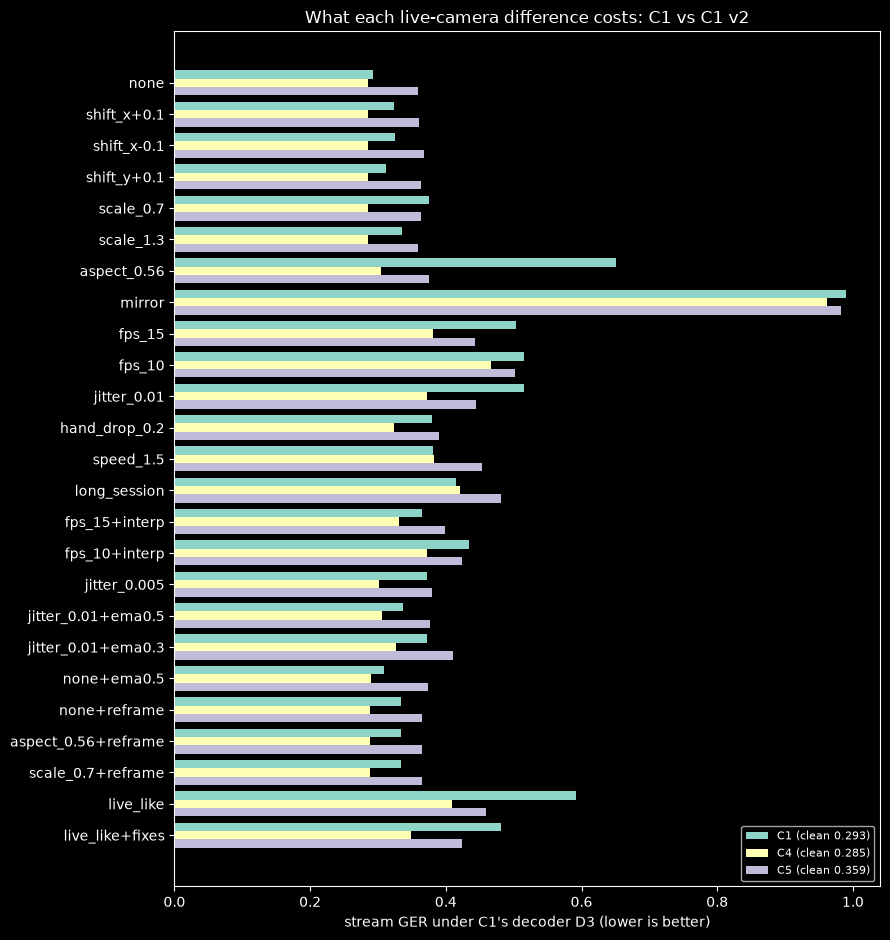

In [6]:
# ============================================================
# ΔGER vs Δ isolated accuracy per probe
# ============================================================
W = SUMMARY["ger"].unstack("run").reindex(list(PROBES)).dropna(how="all")
fig, ax = plt.subplots(figsize=(9, 0.32 * len(W) + 1.5))
yy = np.arange(len(W))
h = 0.8 / W.shape[1]
for k, run in enumerate(W.columns):
    ax.barh(yy - 0.4 + h * (k + 0.5), W[run], height=h, label=f"{run} (clean {W.loc['none', run]:.3f})")
ax.set_yticks(yy, W.index)
ax.invert_yaxis()
ax.set_xlabel("stream GER under C1's decoder D3 (lower is better)")
ax.legend(loc="lower right", fontsize=8)
ax.set_title("What each live-camera difference costs: C1 vs C1 v2")
fig.tight_layout()
fig.savefig(ASSETS / "probes.png", dpi=130)
plt.show()